In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
!pip install mne torch torchvision torchaudio scikit-learn \
            matplotlib numpy seaborn tenseal opacus -q

print("All libraries installed!")

All libraries installed!


In [21]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/NeuroSecure_Dataset'

# Load all 3 files
raw_signals = np.load(f'{BASE}/raw_signals.npy', allow_pickle=True)
X_features  = np.load(f'{BASE}/X_features.npy',  allow_pickle=True)
y_labels    = np.load(f'{BASE}/y_labels.npy',     allow_pickle=True)

# Force float32 for training
raw_signals = raw_signals.astype(np.float32)
X_features  = X_features.astype(np.float32)
y_labels    = y_labels.astype(np.int64) if y_labels.dtype != object \
              else y_labels

print("=" * 40)
print("raw_signals :", raw_signals.shape)
print("X_features  :", X_features.shape)
print("y_labels    :", y_labels.shape)
print("Labels found:", np.unique(y_labels))
print("=" * 40)

raw_signals : (1000, 8, 256)
X_features  : (1000, 96)
y_labels    : (1000,)
Labels found: [0 1]


In [22]:
unique, counts = np.unique(y_labels, return_counts=True)

print("CLASS DISTRIBUTION")
print("-" * 35)
for label, count in zip(unique, counts):
    bar = "█" * int(count / max(counts) * 20)
    pct = 100 * count / len(y_labels)
    print(f"  Class {label} | {bar:<20} | {count} samples ({pct:.1f}%)")

print(f"\nTotal samples : {len(y_labels)}")
print(f"Feature dims  : {X_features.shape[1] if X_features.ndim == 2 else X_features.shape}")
print(f"Signal dims   : {raw_signals.shape}")

# Check alignment
if len(X_features) == len(y_labels):
    print("\nFeatures and labels aligned!")
else:
    print(f"\nWARNING: mismatch! Features={len(X_features)}, Labels={len(y_labels)}")

CLASS DISTRIBUTION
-----------------------------------
  Class 0 | ████████████████████ | 900 samples (90.0%)
  Class 1 | ██                   | 100 samples (10.0%)

Total samples : 1000
Feature dims  : 96
Signal dims   : (1000, 8, 256)

Features and labels aligned!


In [23]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Handle 3D signals → flatten to 2D if needed
# e.g. (1000, 64, 256) → (1000, 64*256)
if raw_signals.ndim == 3:
    n_samples, n_channels, n_times = raw_signals.shape
    raw_2d = raw_signals.reshape(n_samples, n_channels * n_times)
    print(f"Signals reshaped: {raw_signals.shape} → {raw_2d.shape}")
elif raw_signals.ndim == 2:
    raw_2d = raw_signals
    print(f"Signals already 2D: {raw_2d.shape}")
else:
    raw_2d = raw_signals.reshape(len(raw_signals), -1)
    print(f"Signals flattened: {raw_2d.shape}")

# Normalize features
scaler_feat = StandardScaler()
X_scaled    = scaler_feat.fit_transform(X_features)

# Normalize raw signals
scaler_raw  = StandardScaler()
raw_scaled  = scaler_raw.fit_transform(raw_2d)

# Encode labels
le        = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
n_classes = len(le.classes_)

print(f"\nNormalization done!")
print(f"Classes         : {le.classes_}")
print(f"Encoded as      : {np.unique(y_encoded)}")
print(f"Number of classes: {n_classes}")

Signals reshaped: (1000, 8, 256) → (1000, 2048)

Normalization done!
Classes         : [0 1]
Encoded as      : [0 1]
Number of classes: 2


In [24]:
from sklearn.ensemble import IsolationForest

print("Running anomaly detection...")

iso = IsolationForest(
    n_estimators=200,
    contamination=0.1,   # assumes ~10% anomalous
    random_state=42
)
iso.fit(X_scaled)

anomaly_preds  = iso.predict(X_scaled)        # -1=anomaly, 1=normal
anomaly_scores = iso.decision_function(X_scaled)

n_anomalies = np.sum(anomaly_preds == -1)
n_normal    = np.sum(anomaly_preds == 1)

print(f"\nAnomaly Detection Results")
print(f"-" * 35)
print(f"Total samples : {len(anomaly_preds)}")
print(f"Normal        : {n_normal}  ({100*n_normal/len(anomaly_preds):.1f}%)")
print(f"Anomalies     : {n_anomalies} ({100*n_anomalies/len(anomaly_preds):.1f}%)")
print(f"\nAnomaly score range: {anomaly_scores.min():.3f} to {anomaly_scores.max():.3f}")
print("(More negative = more anomalous)")

Running anomaly detection...

Anomaly Detection Results
-----------------------------------
Total samples : 1000
Normal        : 900  (90.0%)
Anomalies     : 100 (10.0%)

Anomaly score range: -0.327 to 0.034
(More negative = more anomalous)


In [25]:
import torch
import torch.nn as nn

class NeuroSecureNet(nn.Module):
    def __init__(self, input_size, n_classes):
        super().__init__()

        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            # Layer 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 4
            nn.Linear(128, 64),
            nn.ReLU(),

            # Output
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

# Test model builds correctly
input_size = X_scaled.shape[1]
model_test = NeuroSecureNet(input_size, n_classes)
dummy      = torch.zeros(4, input_size)
out        = model_test(dummy)

print(f"Model built successfully!")
print(f"Input size  : {input_size}")
print(f"Output size : {out.shape}  (batch=4, classes={n_classes})")
print(f"\nModel summary:")
total_params = sum(p.numel() for p in model_test.parameters())
print(f"Total parameters: {total_params:,}")

Model built successfully!
Input size  : 96
Output size : torch.Size([4, 2])  (batch=4, classes=2)

Model summary:
Total parameters: 224,066


In [26]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Train / test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")

# Convert to PyTorch tensors
X_tr = torch.FloatTensor(X_train)
X_te = torch.FloatTensor(X_test)
y_tr = torch.LongTensor(y_train)
y_te = torch.LongTensor(y_test)

# DataLoaders
train_loader = DataLoader(
    TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
test_loader  = DataLoader(
    TensorDataset(X_te, y_te), batch_size=32, shuffle=False)

# Setup
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = NeuroSecureNet(input_size, n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

print(f"\nTraining on: {device}")
print("Starting training...\n")

# Training loop
EPOCHS   = 60
best_acc = 0.0
history  = {'loss': [], 'acc': []}

for epoch in range(EPOCHS):
    # Train
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    # Evaluate
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            _, preds = torch.max(model(Xb), 1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

    acc     = 100 * correct / total
    avg_loss = total_loss / len(train_loader)
    history['loss'].append(avg_loss)
    history['acc'].append(acc)

    # Save best model
    if acc > best_acc:
        best_acc = acc
        torch.save(
            model.state_dict(),
            '/content/drive/MyDrive/NeuroSecure_Dataset/best_model.pth'
        )

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"Accuracy: {acc:.2f}%"
              + (" ← best!" if acc == best_acc else ""))

print(f"\nTraining complete!")
print(f"Best accuracy : {best_acc:.2f}%")
print(f"Model saved to Drive!")

Train samples : 800
Test samples  : 200

Training on: cuda
Starting training...

Epoch  10/60 | Loss: 0.0081 | Accuracy: 99.00%
Epoch  20/60 | Loss: 0.0015 | Accuracy: 100.00% ← best!
Epoch  30/60 | Loss: 0.0003 | Accuracy: 100.00% ← best!
Epoch  40/60 | Loss: 0.0003 | Accuracy: 100.00% ← best!
Epoch  50/60 | Loss: 0.0003 | Accuracy: 100.00% ← best!
Epoch  60/60 | Loss: 0.0004 | Accuracy: 100.00% ← best!

Training complete!
Best accuracy : 100.00%
Model saved to Drive!


In [27]:
import tenseal as ts

print("Setting up encryption...")

# Create CKKS encryption context
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
context.global_scale = 2**40
context.generate_galois_keys()
print("Encryption context ready!")

# Encrypt first 5 samples as demo
print("\nEncrypting 5 EEG feature samples...")
print("-" * 50)

encrypted_samples = []
for i in range(5):
    enc = ts.ckks_vector(context, X_scaled[i].tolist())
    encrypted_samples.append(enc)

    # Verify by decrypting back
    decrypted = np.array(enc.decrypt())
    error     = np.mean(np.abs(decrypted - X_scaled[i]))

    label     = le.classes_[y_encoded[i]]
    anomaly   = "ANOMALY" if anomaly_preds[i] == -1 else "normal"

    print(f"Sample {i+1} | Label: {label:<10} | "
          f"Anomaly: {anomaly:<8} | "
          f"Encrypt error: {error:.8f}")

print("-" * 50)
print("Encryption working correctly!")
print("(Error values near 0 = perfect encryption/decryption)")

Setting up encryption...
Encryption context ready!

Encrypting 5 EEG feature samples...
--------------------------------------------------
Sample 1 | Label: 0          | Anomaly: normal   | Encrypt error: 0.00000000
Sample 2 | Label: 0          | Anomaly: normal   | Encrypt error: 0.00000000
Sample 3 | Label: 0          | Anomaly: normal   | Encrypt error: 0.00000000
Sample 4 | Label: 0          | Anomaly: normal   | Encrypt error: 0.00000000
Sample 5 | Label: 0          | Anomaly: normal   | Encrypt error: 0.00000000
--------------------------------------------------
Encryption working correctly!
(Error values near 0 = perfect encryption/decryption)


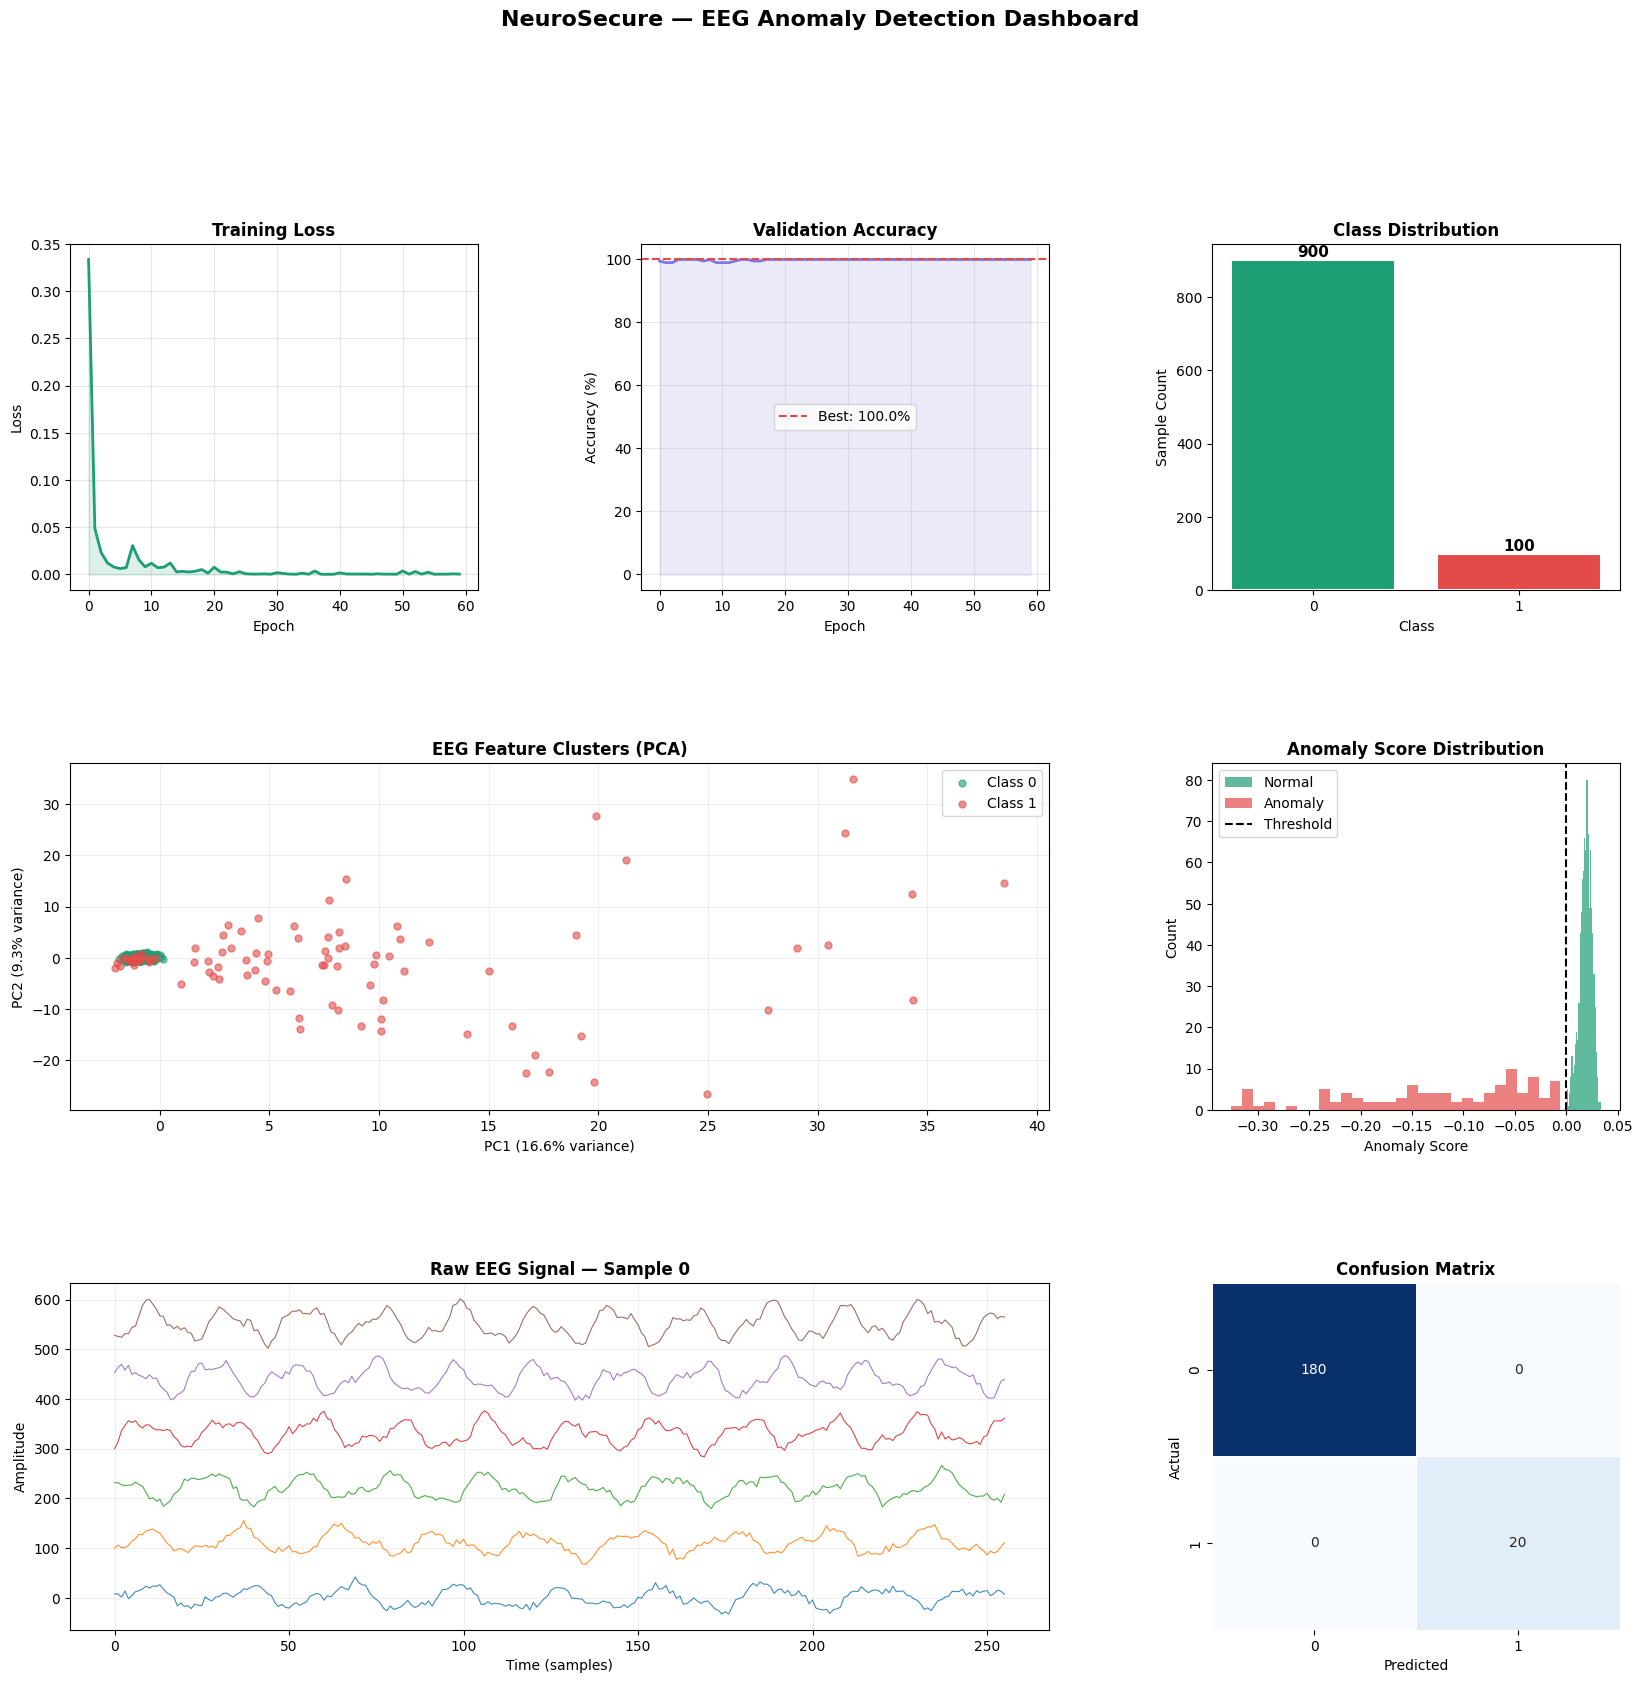

Dashboard saved to Drive!

CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [28]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA

# Collect predictions
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        _, preds = torch.max(model(Xb.to(device)), 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

# ── Build dashboard ──────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# 1. Training loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['loss'], color='#1D9E75', linewidth=2)
ax1.fill_between(range(len(history['loss'])),
                 history['loss'], alpha=0.15, color='#1D9E75')
ax1.set_title('Training Loss', fontweight='bold', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

# 2. Validation accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['acc'], color='#7F77DD', linewidth=2)
ax2.fill_between(range(len(history['acc'])),
                 history['acc'], alpha=0.15, color='#7F77DD')
ax2.axhline(y=best_acc, color='#E24B4A', linestyle='--',
            linewidth=1.5, label=f'Best: {best_acc:.1f}%')
ax2.set_title('Validation Accuracy', fontweight='bold', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Class distribution
ax3 = fig.add_subplot(gs[0, 2])
class_names = [str(c) for c in le.classes_]
bar_colors  = ['#E24B4A' if i == 1 else '#1D9E75'
               for i in range(n_classes)]
ax3.bar(class_names, counts, color=bar_colors, edgecolor='white', linewidth=1.5)
ax3.set_title('Class Distribution', fontweight='bold', fontsize=12)
ax3.set_xlabel('Class')
ax3.set_ylabel('Sample Count')
for i, (name, count) in enumerate(zip(class_names, counts)):
    ax3.text(i, count + max(counts)*0.01, str(count),
             ha='center', fontweight='bold', fontsize=11)

# 4. PCA cluster plot
ax4 = fig.add_subplot(gs[1, :2])
pca      = PCA(n_components=2, random_state=42)
n_plot   = min(1000, len(X_scaled))
X_pca    = pca.fit_transform(X_scaled[:n_plot])
y_plot   = y_encoded[:n_plot]
palette  = ['#1D9E75', '#E24B4A', '#7F77DD', '#BA7517', '#378ADD']

for cls_idx in range(n_classes):
    mask = y_plot == cls_idx
    ax4.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Class {le.classes_[cls_idx]}',
        alpha=0.6, s=25,
        color=palette[cls_idx % len(palette)]
    )

ax4.set_title('EEG Feature Clusters (PCA)',
              fontweight='bold', fontsize=12)
ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax4.legend()
ax4.grid(alpha=0.2)

# 5. Anomaly score distribution
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(anomaly_scores[anomaly_preds == 1],
         bins=30, color='#1D9E75', alpha=0.7, label='Normal')
ax5.hist(anomaly_scores[anomaly_preds == -1],
         bins=30, color='#E24B4A', alpha=0.7, label='Anomaly')
ax5.axvline(x=0, color='black', linewidth=1.5,
            linestyle='--', label='Threshold')
ax5.set_title('Anomaly Score Distribution',
              fontweight='bold', fontsize=12)
ax5.set_xlabel('Anomaly Score')
ax5.set_ylabel('Count')
ax5.legend()

# 6. Raw EEG signal plot
ax6 = fig.add_subplot(gs[2, :2])
sample_signal = raw_signals[0]

if sample_signal.ndim == 2:
    # (channels, time) — plot first 6 channels
    n_ch   = min(6, sample_signal.shape[0])
    offset = np.max(np.abs(sample_signal)) * 2
    for ch in range(n_ch):
        ax6.plot(sample_signal[ch] + ch * offset,
                 linewidth=0.8, alpha=0.85,
                 label=f'Ch {ch+1}')
    ax6.set_xlabel('Time (samples)')
else:
    # 1D signal
    ax6.plot(sample_signal, color='#1D9E75', linewidth=1)
    ax6.set_xlabel('Time (samples)')

ax6.set_title('Raw EEG Signal — Sample 0',
              fontweight='bold', fontsize=12)
ax6.set_ylabel('Amplitude')
ax6.grid(alpha=0.2)

# 7. Confusion matrix
ax7 = fig.add_subplot(gs[2, 2])
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax7, cbar=False, linewidths=0.5
)
ax7.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
ax7.set_xlabel('Predicted')
ax7.set_ylabel('Actual')

plt.suptitle(
    'NeuroSecure — EEG Anomaly Detection Dashboard',
    fontsize=16, fontweight='bold', y=1.01
)

# Save to Drive
save_path = '/content/drive/MyDrive/NeuroSecure_Dataset/dashboard.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Dashboard saved to Drive!")

# Print classification report
print("\nCLASSIFICATION REPORT")
print("-" * 40)
print(classification_report(all_true, all_preds,
      target_names=class_names))